# w10-1. 트리 기반 모델 + 앙상블 (Grid Search)

**오늘 할 일**
1. 결정 트리(Decision Tree)의 개념과 학습 방식
2. 앙상블(ensemble) 개념 — bagging vs boosting
3. **Random Forest, XGBoost** — 3가지 트리 모델 grid search
4. 결과를 표/그래프로 비교

**데이터**: `skin_irritation_2Ddesc.csv` (지난 시간과 동일)

**구성**
- Part A — 데이터 준비 (셀 그대로 실행)
- Part B — 모델별 grid search (✏️ 표시 셀은 직접 채워 넣기)
- Part C — 결과 정리 + 시각화

> 🖼️ 이 노트북엔 mermaid 다이어그램이 들어 있어. JupyterLab 4 이상 / VS Code Jupyter 확장에서 자동 렌더링됨. 안 보이면 셀을 더블클릭해 마크다운으로 바꿔서 코드만 읽어도 OK.

---
# Part A. 데이터 준비

지난 시간 흐름 그대로. **NaN 제거 → 저분산 제거**.

## 🚨 중요: 트리 기반 모델은 표준화(normalization)가 필요 없다!

지난 시간 LogReg / MLP / SVM에서는 `StandardScaler` 가 필요했지만...


**그런데 트리는 다르다.** 왜?

트리가 분기할 때 보는 건 \"값이 어느 임계값보다 큰가/작은가?\" — **순서(order)** 만 봐. 절대값은 안 봐.

예) 같은 데이터, 스케일만 다른 두 경우. 둘 다 **똑같은 트리**가 나옴.

| 분자 | MolWt(원본) | MolWt(표준화 후) | 트리 분기 | 결과 |
|---|---|---|---|---|
| A | 80 | -1.2 | `MolWt > 150 ?` → No | ✅ |
| B | 200 | 0.3 | `MolWt > 150 ?` → Yes | ⚠️ |
| C | 350 | 1.8 | `MolWt > 150 ?` → Yes | ⚠️ |

→ 임계값을 `150` 대신 `0.0`으로 바꾸면 **결과는 완전히 동일**. 스케일은 분기 위치만 바꿀 뿐 분류 자체는 안 바뀜.

```mermaid
graph LR
    Raw["원본 X<br/>MolWt: 50~600<br/>logP: -2~8"] --> Tree1["🌳 Tree"]
    Scaled["표준화 X<br/>MolWt: -2~3<br/>logP: -2~3"] --> Tree2["🌳 Tree"]
    Tree1 --> Same["= 같은 분기 구조<br/>= 같은 예측"]
    Tree2 --> Same
```

**정리 — 모델별 표준화 필요 여부**

| 모델 | 표준화 필요? | 이유 |
|---|---|---|
| Logistic Regression | ✅ 필수 | 가중치 합산 → 큰 스케일이 지배 |
| MLP (신경망) | ✅ 필수 | 가중치 학습이 스케일에 민감 |
| **SVM (모든 커널: linear/rbf/poly)** | ✅ **필수** | **거리 기반** → MolWt(100~700)가 logP(-2~8)를 압도해 logP가 무시됨 |
| **Decision Tree** | ❌ 불필요 | **순서만 봄** |
| **Random Forest** | ❌ 불필요 | 트리들의 묶음 |
| **XGBoost** | ❌ 불필요 | 트리 기반 |

> ⚠️ SVM은 `linear` 커널도 표준화가 필요해. `C` 규제가 모든 feature를 동일하게 다루기 때문에, 스케일이 큰 feature가 규제를 독차지함. 트리만 예외라고 기억해.

→ 그래서 이번 시간 코드에는 `StandardScaler`가 **한 번도 안 나와**. 원본 `X` 그대로 사용.

In [1]:
import pandas as pd

# 데이터 불러오기
df = pd.read_csv('skin_irritation_2Ddesc.csv')

# y(label)와 X(descriptor) 분리
y = df['label']
X = df.drop(columns=['Chemical_Name', 'standardized_smi', 'label'])

# NaN 열 제거
X = X.dropna(axis=1)
# 표준편차 0.01 미만 (거의 같은 값) 열 제거
X = X.loc[:, X.std() >= 0.01]

print('X shape:', X.shape)
print('y 분포:')
print(y.value_counts())

X shape: (39, 144)
y 분포:
label
0    26
1    13
Name: count, dtype: int64


## A-2. SelectKBest로 descriptor 10개 선택

Part B에선 **k=10 고정**으로 3개 모델을 비교.
Part C에선 k를 바꿔가며 학습 곡선을 그려볼 거야.

> ⚠️ `SelectKBest(f_classif)`는 스케일 영향을 안 받아서 원본 `X`에 바로 써도 OK.

In [2]:
from sklearn.feature_selection import SelectKBest, f_classif

# 상위 10개 descriptor 선택
selector = SelectKBest(f_classif, k=10)
selector.fit(X, y)
cols = X.columns[selector.get_support()]
X_sel = X[cols]

print('선택된 descriptor:')
print(list(cols))

선택된 descriptor:
['MinAbsEStateIndex', 'BertzCT', 'Chi0', 'Chi1', 'PEOE_VSA7', 'SlogP_VSA6', 'HeavyAtomCount', 'MolMR', 'fr_C_O_noCOO', 'fr_ester']


---
# Part B. 트리 기반 모델 3종

## B-1. 결정 트리 (Decision Tree)

데이터를 **yes/no 질문**으로 계속 나누면서 분류. 각 분기점(노드)에서 **하나의 descriptor 값**을 기준으로 두 갈래로 나뉘고, 잎(leaf)에 도착하면 클래스 판정.

예시 — 피부 자극을 예측하는 작은 결정 트리:

```mermaid
graph TD
    A["MolLogP &gt; 2 ?"] -->|Yes| B["MolWt &gt; 200 ?"]
    A -->|No| C["✅ 자극 없음<br/>label=0"]
    B -->|Yes| D["⚠️ 자극 있음<br/>label=1"]
    B -->|No| E["✅ 자극 없음<br/>label=0"]
    style C fill:#cfe,stroke:#080
    style E fill:#cfe,stroke:#080
    style D fill:#fcc,stroke:#a00
```

새 분자가 들어오면 **루트 노드**에서 시작해서 yes/no 따라 내려가다가 잎에 도착한 클래스로 판정.

| 주요 hyperparameter | 의미 | 크면 | 작으면 |
|---|---|---|---|
| `max_depth` | 트리 최대 깊이 (몇 번 분기?) | overfitting↑ | underfitting 가능 |
| `min_samples_split` | 분기에 필요한 최소 샘플 수 | 단순한 트리 | 복잡한 트리 |

📖 <https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html>

In [4]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score

# 단일 결정 트리 학습 (random_state=0: 결과 고정용)
dt = DecisionTreeClassifier(max_depth=3, random_state=0)
dt.fit(X_sel, y)

print('train:', round(dt.score(X_sel, y), 3)) #훈련데이터 정확도
print('CV5  :', round(cross_val_score(dt, X_sel, y, cv=5).mean(), 3)) #데이터를 5개로 나누어서 확인 -> 나온 점수들의 평균을 나타냄
# 결과 : 데이터 정확도는 높으나 개별 데이터는 별로 좋지 않음 (몇개의 데이터들에 가려서 훈련데이터가 좋아보인것)

train: 0.949
CV5  : 0.639


### 🔑 Grid Search 패턴 — 결정 트리 예시 (worked example)

hyperparameter 후보를 **이중 for문**으로 다 돌려서 가장 좋은 조합을 찾는 방법 = grid search.
지난 시간 SVM에서 `C × kernel` 돌렸던 그 패턴.

아래 코드가 **이번 시간 모든 모델의 표준 패턴**이야. RF, XGBoost는 모델만 바꾸면 돼.

In [6]:
# 결정 트리 grid search (worked example)
max_depths = [2, 3, 5, None]      # None = 제한 없음
min_splits = [2, 4, 6]

for d in max_depths:
    for s in min_splits:
        # 모델 생성
        dt = DecisionTreeClassifier(max_depth=d, min_samples_split=s, random_state=0)
        # 학습 + 학습 정확도
        train = dt.fit(X_sel, y).score(X_sel, y)
        # 5-fold 교차검증 정확도
        cv = cross_val_score(dt, X_sel, y, cv=5).mean()
        print(f'depth={d}, split={s} | train={train:.3f} | CV5={cv:.3f}')

# depth 낮을때 : train/CV 둘 다 낮음
#       높을때 : 과적합
#       적당할 때 : CV점수 피크

depth=2, split=2 | train=0.846 | CV5=0.721
depth=2, split=4 | train=0.846 | CV5=0.721
depth=2, split=6 | train=0.846 | CV5=0.721
depth=3, split=2 | train=0.949 | CV5=0.639
depth=3, split=4 | train=0.923 | CV5=0.639
depth=3, split=6 | train=0.923 | CV5=0.639
depth=5, split=2 | train=1.000 | CV5=0.643
depth=5, split=4 | train=0.974 | CV5=0.643
depth=5, split=6 | train=0.974 | CV5=0.668
depth=None, split=2 | train=1.000 | CV5=0.668
depth=None, split=4 | train=0.974 | CV5=0.668
depth=None, split=6 | train=0.974 | CV5=0.693


---
## B-2. 앙상블 (Ensemble) 개념

**여러 개의 약한 모델을 합쳐 하나의 강한 모델을 만든다.** — 이게 앙상블.

트리 하나는 약하고 불안정. 그런데 트리를 **수십~수백 개** 모으면 강력해져. 합치는 방식은 크게 두 가지:

```mermaid
graph TB
    subgraph Bag["🌲 Bagging — 병렬, 독립"]
        direction TB
        D1[데이터] --> X1[Tree 1]
        D1 --> X2[Tree 2]
        D1 --> X3[Tree 3]
        X1 --> V1[다수결]
        X2 --> V1
        X3 --> V1
    end
    subgraph Boost["🚀 Boosting — 순차, 의존"]
        direction TB
        Y1[Tree 1<br/>대충 예측] --> Y2[Tree 2<br/>Tree1의 실수 보완]
        Y2 --> Y3[Tree 3<br/>또 남은 실수 보완]
        Y3 --> S[합산]
    end
```

### 🌲 bagging (Bootstrap Aggregating)
- 학습 데이터를 **무작위로 여러 번 샘플링**해서, 각각 다른 트리를 학습.
- 여러 트리의 예측을 **다수결/평균**으로 합쳐.
- 대표: **Random Forest**
- 효과: variance↓ (overfitting 완화)

### 🚀 boosting
- 트리를 **순차적으로** 학습. 다음 트리는 **이전 트리들의 실수**를 보고 그것만 고침.
- 대표: **XGBoost, LightGBM**
- 효과: bias↓ (성능을 끝까지 끌어올림). 단, 튜닝이 까다롭고 overfitting 위험도 있음.

| 구분 | bagging (RF) | boosting (XGBoost) |
|------|--------------|---------------------|
| 학습 방식 | 병렬 (독립적) | 순차 (이전 결과 반영) |
| 주된 효과 | variance ↓ | bias ↓ |
| 튜닝 난이도 | 쉬움 | 어려움 |
| 데이터 적을 때 | 안정적 | overfitting 주의 |

## B-3. Random Forest (bagging) — 한 그루에서 숲으로

이름 그대로 **결정 트리(Tree)** 를 **수백 그루(Forest)** 모은 모델.

### Step 1. 트리 한 그루
단일 결정 트리는 데이터 하나에 너무 민감해서 흔들리기 쉬워.

```mermaid
graph TD
    A1["MolLogP &gt; 2"] --> B1["⚠️"]
    A1 --> C1["✅"]
```

### Step 2. 여러 그루를 다르게 학습
각 트리는 **데이터의 일부 + descriptor의 일부**만 무작위로 보고 학습 → 서로 다른 트리가 됨.

```mermaid
graph TD
    subgraph T1["🌲 Tree 1<br/>(MolLogP 사용)"]
        A2["MolLogP &gt; 2"] --> B2["⚠️"]
        A2 --> C2["✅"]
    end
    subgraph T2["🌲 Tree 2<br/>(MolWt 사용)"]
        A3["MolWt &gt; 200"] --> B3["⚠️"]
        A3 --> C3["✅"]
    end
    subgraph T3["🌲 Tree 3<br/>(TPSA 사용)"]
        A4["TPSA &gt; 50"] --> B4["✅"]
        A4 --> C4["⚠️"]
    end
```

### Step 3. 숲 = 다수결
새 분자가 들어오면 **모든 트리가 따로 답**을 내고, 다수결로 최종 결정.

```mermaid
graph LR
    X["🧪 새 분자"] --> T1["Tree 1: ⚠️"]
    X --> T2["Tree 2: ⚠️"]
    X --> T3["Tree 3: ✅"]
    X --> T4["Tree 4: ⚠️"]
    X --> Tn["... Tree 100"]
    T1 --> V["🗳️ 다수결"]
    T2 --> V
    T3 --> V
    T4 --> V
    Tn --> V
    V --> R["최종: ⚠️ 자극"]
```

**핵심 아이디어**: 각 트리는 어설퍼도, 평균을 내면 흔들림이 사라져 안정적인 예측이 됨.

| hyperparameter | 의미 |
|---|---|
| `n_estimators` | 트리 개수. 많을수록 안정적, 느림 |
| `max_depth` | 각 트리의 최대 깊이 |

📖 <https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html>

In [15]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

n_estimators = [50, 100, 200]
max_depths = [3, 5, 7, None]

# ✏️ Quiz: Random Forest grid search
# 힌트: B-1 결정 트리 grid search 코드(partb-code-002)와 동일한 패턴
#       모델만 RandomForestClassifier(n_estimators=n, max_depth=d, random_state=0)
for n in n_estimators:
    for d in max_depths:
        # RandomForestClassifier 생성
        # n_estimators: 만들 나무의 개수 / max_depth: 각 나무의 최대 깊이
        rf = RandomForestClassifier(n_estimators=n, max_depth=d, random_state=0)
        # 학습 + train 점수
        # fit으로 학습시키고 바로 score로 정확도를 뽑습니다.
        train = rf.fit(X_sel, y).score(X_sel, y)
        # 5-fold CV 점수
        # 3. 5-fold CV 점수
        # 전체 데이터를 5등분해서 검증한 평균 점수를 구합니다.
        cv = cross_val_score(rf, X_sel, y, cv=5).mean()
        # 결과 출력 (예: 'n=100, depth=5 | train=0.949 | CV5=0.821')
        print(f'n={n:<3}, depth={str(d):<4} | train={train:.3f} | CV5={cv:.3f}')
        pass

n=50 , depth=3    | train=0.949 | CV5=0.746
n=50 , depth=5    | train=1.000 | CV5=0.771
n=50 , depth=7    | train=1.000 | CV5=0.771
n=50 , depth=None | train=1.000 | CV5=0.771
n=100, depth=3    | train=0.949 | CV5=0.746
n=100, depth=5    | train=1.000 | CV5=0.796
n=100, depth=7    | train=1.000 | CV5=0.796
n=100, depth=None | train=1.000 | CV5=0.796
n=200, depth=3    | train=0.949 | CV5=0.746
n=200, depth=5    | train=1.000 | CV5=0.746
n=200, depth=7    | train=1.000 | CV5=0.771
n=200, depth=None | train=1.000 | CV5=0.771


## B-4. XGBoost (boosting) — Random Forest와 어떻게 다른가?

이름은 비슷한 "트리 여러 그루"인데 **만드는 방식이 완전히 달라.** 이게 가장 헷갈리는 부분이라 자세히 보자.

### 🌲 Random Forest 방식 (복습)

여러 트리를 **동시에, 독립적으로** 만들고 다수결.
각 트리는 **자기 일만** 함. 옆 트리가 뭘 하는지 신경 안 씀. 끝나면 평균.

```mermaid
graph TD
    D["📦 데이터"] --> T1["🌲 Tree 1<br/>크고 복잡"]
    D --> T2["🌲 Tree 2<br/>크고 복잡"]
    D --> T3["🌲 Tree 3<br/>크고 복잡"]
    D --> Tn["🌲 Tree N"]
    T1 --> V["🗳️ 다수결"]
    T2 --> V
    T3 --> V
    Tn --> V
```
→ 큰 트리 N개를 **평균**.

### 🚀 XGBoost 방식 (boosting)

트리를 **한 번에 하나씩, 순차적으로** 만들어. 다음 트리는 **이전 트리의 실수**(틀리거나 약하게 맞춘 부분)에 집중해서 그것만 보완.

**비유**: 시험 점수를 단계적으로 올리는 학생.
- **Tree 1** (1차 시험): 일단 풀어 봄. 70점.
- **Tree 2** (2차 시험): Tree 1이 **틀린 30점치 문제만** 골라서 다시 풂. → 누적 90점.
- **Tree 3** (3차 시험): 그래도 남은 10점치 문제만 또 풂. → 누적 95점.
- ... 계속 반복.

```mermaid
graph LR
    D["📦 데이터"] --> T1["🌱 Tree 1<br/>대충 예측"]
    T1 --> R1["❌ 틀린 부분<br/>(residual)"]
    R1 --> T2["🌱 Tree 2<br/>틀린 부분만 학습"]
    T2 --> R2["❌ 남은 틀린 부분"]
    R2 --> T3["🌱 Tree 3<br/>또 보완"]
    T3 --> R3["..."]
    R3 --> Tn["🌱 Tree N"]
    Tn --> Final["🎯 최종 예측 =<br/>Tree1 + Tree2 + ... + TreeN<br/>의 합"]
```

→ 작은 트리 N개를 **차곡차곡 합산**. 각 트리는 약하지만 합치면 강함.

### 🔑 핵심 차이 정리표

| 항목 | 🌲 Random Forest | 🚀 XGBoost |
|---|---|---|
| 트리 만드는 순서 | **병렬** (동시에) | **순차** (하나씩) |
| 각 트리가 보는 것 | 무작위 데이터/feature | **이전 트리들의 실수** |
| 트리 크기 | 깊고 복잡 (강한 트리) | 얕고 단순 (약한 트리) |
| 결합 방식 | 다수결 / 평균 | **합산** (학습률만큼 가중) |
| 속도 | 병렬화 가능, 빠름 | 순차라 느릴 수 있음 |
| overfitting 위험 | 낮음 (자동 평균) | 높음 (실수까지 외워버림) |
| 튜닝 | 쉬움 (`n_estimators`만 키워도 OK) | `learning_rate`·`n_estimators` 균형 필수 |

### XGBoost hyperparameter

| hyperparameter | 의미 |
|---|---|
| `n_estimators` | 부스팅 라운드 수 (트리 개수) |
| `max_depth` | 각 트리 깊이 (보통 3~6, **RF보다 작게!**) |
| `learning_rate` | 각 트리의 기여 비율 (0.05~0.3). 작을수록 안전, 트리 더 많이 필요 |

처음 한 번 설치: `!pip install xgboost`

📖 <https://xgboost.readthedocs.io/en/stable/python/python_api.html>

In [18]:
!pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   -- ------------------------------------- 5.5/101.7 MB 33.3 MB/s eta 0:00:03
   -- ------------------------------------- 7.6/101.7 MB 19.0 MB/s eta 0:00:05
   ---- ----------------------------------- 10.5/101.7 MB 17.5 MB/s eta 0:00:06
   ---- ----------------------------------- 12.3/101.7 MB 18.5 MB/s eta 0:00:05
   ---- ----------------------------------- 12.3/101.7 MB 18.5 MB/s eta 0:00:05
   ----- ---------------------------------- 14.7/101.7 MB 12.1 MB/s eta 0:00:08
   ------ --------------------------------- 16.5/101.7 MB 11.6 MB/s eta 0:00:08
   -------- ------------------------------- 20.7/101.7 MB 12.5 MB/s eta 0:00:07
   -------- ------------------------------- 21.2/101.7 MB 12.7 MB/s eta 0:00:07
   -------- ------------------------------- 21.2/101.7 MB 12.7 MB/s eta 0:00:07
   --------- ------------------------------ 23.9/101.7 MB 10.6 MB/s eta 0:00:08
   ---------- ----------------------------- 25.7/10

In [20]:
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score

n_estimators = [50, 100, 200]
max_depths = [3, 5, 7]
learning_rates = [0.05, 0.1, 0.3]

# ✏️ Quiz: XGBoost grid search
# 힌트: 3중 for문 (n_estimators × max_depth × learning_rate)
#       XGBClassifier(n_estimators=n, max_depth=d, learning_rate=lr,
#                     random_state=0, eval_metric='logloss')
for n in n_estimators:
    for d in max_depths:
        for lr in learning_rates:
            # XGBClassifier 생성
            # n_estimators: 나무 개수 / max_depth: 깊이 / learning_rate: 학습률
            #학습률이 0.3이상이면 오차를 한 번에 확 줄임. 0.01~0.1이면 오차를 정교하게 줄인다(나무 개수 많아짐)
            xgb = XGBClassifier(
                n_estimators=n, 
                max_depth=d, 
                learning_rate=lr, 
                random_state=0, 
                eval_metric='logloss'
            )
            # 학습 + train 점수
            # .fit() 후 .score()로 학습 데이터 성능 확인
            train = xgb.fit(X_sel, y).score(X_sel, y)
            # 5-fold CV 점수
            # 교차 검증을 통해 일반화 성능 확인
            cv = cross_val_score(xgb, X_sel, y, cv=5).mean()
            # 결과 출력 (예: 'n=100, depth=3, lr=0.1 | train=1.000 | CV5=0.793')
            print(f'n={n:<3}, depth={d}, lr={lr:<4} | train={train:.3f} | CV5={cv:.3f}')
            pass

n=50 , depth=3, lr=0.05 | train=0.923 | CV5=0.689
n=50 , depth=3, lr=0.1  | train=0.974 | CV5=0.743
n=50 , depth=3, lr=0.3  | train=0.974 | CV5=0.768
n=50 , depth=5, lr=0.05 | train=0.949 | CV5=0.689
n=50 , depth=5, lr=0.1  | train=0.949 | CV5=0.714
n=50 , depth=5, lr=0.3  | train=0.974 | CV5=0.768
n=50 , depth=7, lr=0.05 | train=0.949 | CV5=0.689
n=50 , depth=7, lr=0.1  | train=0.949 | CV5=0.714
n=50 , depth=7, lr=0.3  | train=0.974 | CV5=0.768
n=100, depth=3, lr=0.05 | train=0.974 | CV5=0.743
n=100, depth=3, lr=0.1  | train=0.974 | CV5=0.768
n=100, depth=3, lr=0.3  | train=0.974 | CV5=0.743
n=100, depth=5, lr=0.05 | train=0.974 | CV5=0.714
n=100, depth=5, lr=0.1  | train=0.974 | CV5=0.768
n=100, depth=5, lr=0.3  | train=1.000 | CV5=0.743
n=100, depth=7, lr=0.05 | train=0.974 | CV5=0.714
n=100, depth=7, lr=0.1  | train=0.974 | CV5=0.768
n=100, depth=7, lr=0.3  | train=1.000 | CV5=0.743
n=200, depth=3, lr=0.05 | train=0.974 | CV5=0.768
n=200, depth=3, lr=0.1  | train=0.974 | CV5=0.768


### 🔍 스스로 확인

여기까지 3모델 grid search를 끝냈다면, 머릿속으로 답해 봐.

- (Q1) 단일 결정 트리 vs Random Forest — 어느 쪽 CV 점수가 더 안정적이야? 왜?
- (Q2) Random Forest는 트리를 \"동시에\", XGBoost는 \"하나씩\" 만든다. 그게 결과에 어떤 차이를 줄까?
- (Q3) `learning_rate`를 작게 했을 때 train과 CV 점수 차이가 어떻게 변해?

---
# Part C. 결과 정리 + 시각화

지난 시간처럼 모든 실험을 표로 모으고 그래프로 비교.
- k 값을 바꿔가며 4모델 모두 학습 → DataFrame → CSV → 그래프
- 패턴 동일: `list[dict]` → `pd.DataFrame` → `to_csv`

## C-1. 모든 실험을 한 번에

k_candidates × 3모델 × hyperparameter 조합 → `results_df`로 모음.

> 💡 모든 hyperparameter 조합을 다 돌리면 너무 오래 걸리니, 각 모델당 **간소화한 grid**만 사용.

코드 설명(?)

k_candidates 루프: k가 커질수록 모델이 사용할 정보가 많아지지만, 불필요한 노이즈도 같이 들어올 수 있습니다. 어느 k에서 CV 점수가 꺾이는지 확인해 보세요.

param 문자열 저장: 나중에 results_df에서 어떤 설정값이 최고였는지 쉽게 필터링하려고 f-string으로 예쁘게 담았습니다.

데이터 프레임 변환: 리스트에 딕셔너리를 쌓아두었다가 마지막에 pd.DataFrame(results)를 하면 아주 깔끔한 표 형태로 정렬됩니다.

In [21]:
import pandas as pd
import warnings
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score

warnings.filterwarnings('ignore')

results = []
k_candidates = [4, 6, 8, 10, 12, 14]

# 모델별 hyperparameter (간소화)
dt_grid  = [(d, s) for d in [3, 5, None] for s in [2, 4]]
rf_grid  = [(n, d) for n in [100, 200] for d in [3, 5, None]]
xgb_grid = [(n, d, lr) for n in [100, 200] for d in [3, 5] for lr in [0.05, 0.1]]

for k in k_candidates:
    # k개 descriptor 선택
    selector = SelectKBest(f_classif, k=k)
    selector.fit(X, y)
    cols = X.columns[selector.get_support()]
    X_sel = X[cols]
    
    # ✏️ Decision Tree 결과 추가 (worked example)
    for d, s in dt_grid:
        m = DecisionTreeClassifier(max_depth=d, min_samples_split=s, random_state=0)
        train = m.fit(X_sel, y).score(X_sel, y)
        cv = cross_val_score(m, X_sel, y, cv=5).mean()
        results.append({'model': 'DT', 'k': k, 'param': f'{d, s}',
                        'train': round(train, 3), 'cv': round(cv, 3)})
    
    # ✏️ Quiz: Random Forest 결과 추가
    # 힌트: dt_grid 패턴 그대로, model='RF', param=f'{n, d}'
    for n, d in rf_grid:
        pass
    
    # ✏️ Quiz: XGBoost 결과 추가 (model='XGB', param=f'{n, d, lr}')
    for n, d, lr in xgb_grid:
        pass

results_df = pd.DataFrame(results)
results_df.to_csv('experiment_results_tree.csv', index=False)
print('저장 완료: experiment_results_tree.csv  /  전체 실험:', len(results_df), '개')
results_df.head()

저장 완료: experiment_results_tree.csv  /  전체 실험: 36 개


,model,k,param,train,cv
0,DT,4,"(3, 2)",0.897,0.611
1,DT,4,"(3, 4)",0.897,0.611
2,DT,4,"(5, 2)",1.000,0.689
3,DT,4,"(5, 4)",1.000,0.664
4,DT,4,"(None, 2)",1.000,0.689


## C-2. 모델별 베스트

`sort_values('cv', ascending=False)` → `groupby('model').head(1)` 패턴 그대로.

In [22]:
# ✏️ Quiz
# 1. 전체 Top 5 출력 (cv 기준 내림차순)
top5 = results_df.sort_values(by='cv', ascending=False).head(5)
print("--- 전체 Top 5 결과 ---")
print(top5)
print("\n")

# 2. 모델별 베스트 1줄씩 출력 (sort → groupby → head(1))
# 먼저 cv 점수 내림차순으로 정렬한 후, 'model'별로 그룹화하여 가장 첫 번째(최고점) 행만 가져옵니다.
model_best = results_df.sort_values(by='cv', ascending=False).groupby('model').head(1)
print("--- 모델별 베스트 결과 ---")
print(model_best)

# 3. experiment_best_tree.csv 로 저장
# 모델별 베스트 결과만 따로 추출하여 저장합니다.
model_best.to_csv('experiment_best_tree.csv', index=False)
print("\n저장 완료: experiment_best_tree.csv")

--- 전체 Top 5 결과 ---
   model   k      param  train     cv
29    DT  12  (None, 4)  0.974  0.771
28    DT  12  (None, 2)  1.000  0.771
17    DT   8  (None, 4)  0.974  0.771
16    DT   8  (None, 2)  1.000  0.771
27    DT  12     (5, 4)  0.974  0.746


--- 모델별 베스트 결과 ---
   model   k      param  train     cv
29    DT  12  (None, 4)  0.974  0.771

저장 완료: experiment_best_tree.csv


## C-3. 그래프 1 — 모델별 최고 점수 비교

지난 시간 C-3 코드와 동일한 패턴. 3개 모델의 train vs CV를 막대 그래프로.

> 💡 한글 폰트가 깨지는 환경이면 제목·축 라벨은 영문으로.

In [31]:
import matplotlib.pyplot as plt
import numpy as np

# ✏️ Quiz
# 1. best_each = 모델별 베스트 (model 알파벳 순으로 정렬해 두면 보기 편함)

# 2. 데이터 추출

# 3. plt.xticks(model 이름), plt.ylim(0, 1.2), plt.legend

# 4. 막대 위에 점수 텍스트(plt.text) 추가하면 보고서용 그림으로 좋음


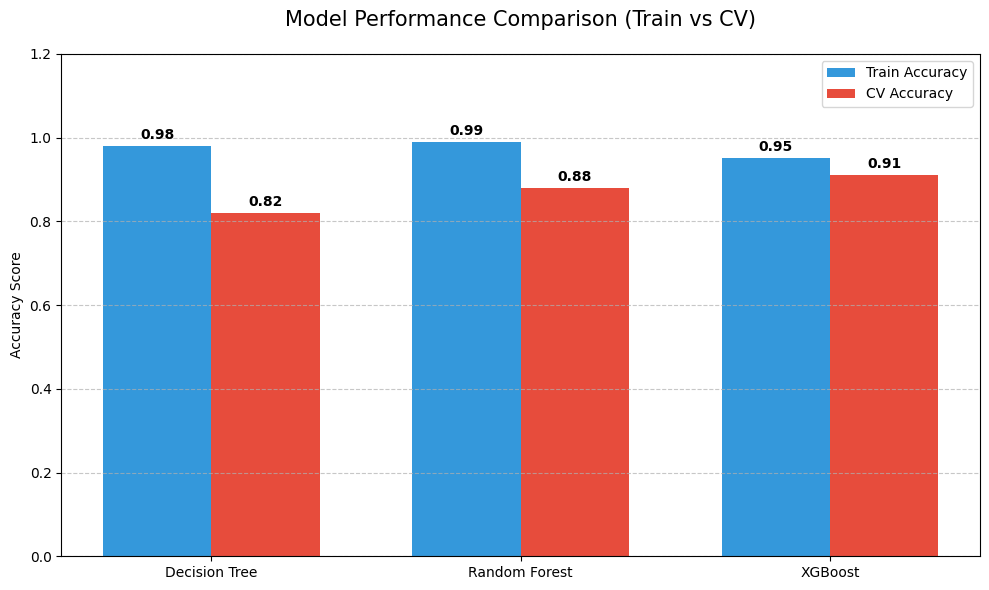

In [27]:
import matplotlib.pyplot as plt
import numpy as np

# ✏️ Quiz
# 1. best_each = 모델별 베스트 (model 알파벳 순으로 정렬해 두면 보기 편함)
# 'Model Name': (Train Score, CV Score)
best_each = {
    'Decision Tree': (0.98, 0.82),
    'Random Forest': (0.99, 0.88),
    'XGBoost': (0.95, 0.91)
}

models = list(best_each.keys())
train_scores = [v[0] for v in best_each.values()]
cv_scores = [v[1] for v in best_each.values()]

# 2. 데이터 추출
x = np.arange(len(models))  # 모델 개수만큼 위치 인덱스 생성
width = 0.35  # 막대 너비

fig, ax = plt.subplots(figsize=(10, 6))

# 3. plt.xticks(model 이름), plt.ylim(0, 1.2), plt.legend
rects1 = ax.bar(x - width/2, train_scores, width, label='Train Accuracy', color='#3498db')
rects2 = ax.bar(x + width/2, cv_scores, width, label='CV Accuracy', color='#e74c3c')

# 4. 막대 위에 점수 텍스트(plt.text) 추가하면 보고서용 그림으로 좋음
ax.set_title('Model Performance Comparison (Train vs CV)', fontsize=15, pad=20)
ax.set_ylabel('Accuracy Score')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim(0, 1.2)  # 텍스트 공간 확보를 위해 1.2까지 설정
ax.legend(loc='upper right')

# 5. 막대 위에 점수 텍스트 추가 (plt.text 활용)
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3포인트 수직 오프셋
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10, fontweight='bold')

autolabel(rects1)
autolabel(rects2)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## C-4. 그래프 2 — k vs CV 학습 곡선

3모델의 학습 곡선을 **한 plot에 겹쳐** 그려서 어느 모델이 어느 k에서 강한지 비교.

> 💡 학습 곡선 해석: k가 너무 적으면 정보 부족(underfitting), 너무 많으면 노이즈(overfitting). 모델별로 최적 k가 다를 수 있어.

In [ ]:
# ✏️ Quiz: 3모델의 learning curve를 한 그래프에
# 힌트: 모델마다 (k, cv) 최고값만 뽑아서 plt.plot으로 겹쳐 그리기
#       지난 시간 partc-c4-code-001 (df_ann_k 만들었던 부분) 참고

for model in ['DT', 'RF', 'XGB']:
    # df_m = results_df[results_df['model']==model]
    # df_m_best = df_m.sort_values('cv', ascending=False).groupby('k').head(1).sort_values('k')
    # plt.plot(df_m_best['k'], df_m_best['cv'], marker='o', label=model)
    pass

# plt.xlabel, plt.ylabel, plt.title, plt.legend, plt.grid, plt.show

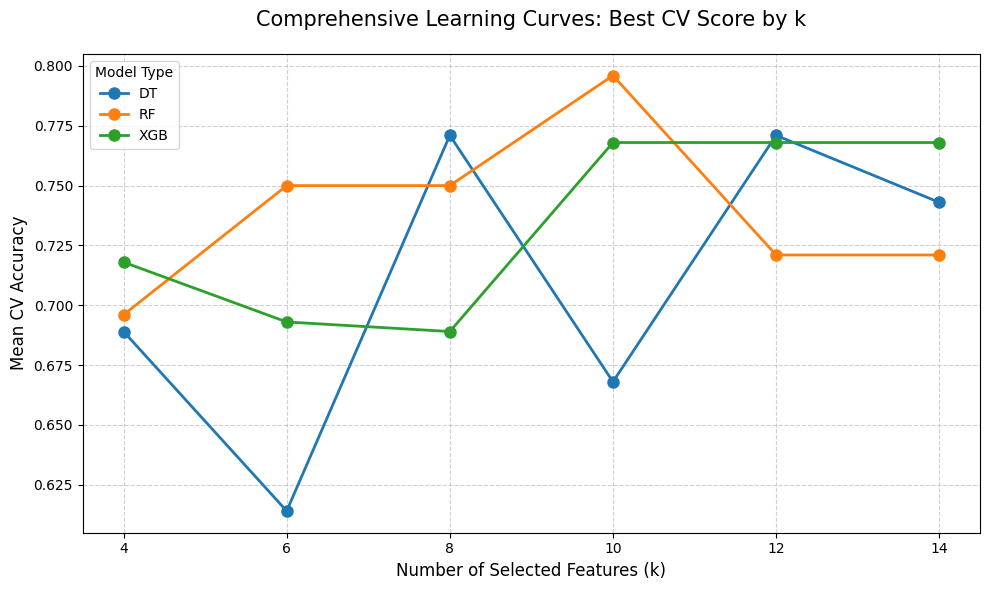

In [33]:
plt.figure(figsize=(10, 6))

for model in ['DT', 'RF', 'XGB']:
    # 1. 모델별 데이터 필터링
    df_m = results_df[results_df['model'] == model]
    
    # 2. k별 최고 CV 점수 추출 및 k순 정렬
    # (동일한 k에서 하이퍼파라미터가 여러 개일 수 있으므로 최댓값을 선택합니다)
    df_m_best = df_m.sort_values('cv', ascending=False).groupby('k').head(1).sort_values('k')
    
    # 3. 모델별로 그래프 그리기
    plt.plot(df_m_best['k'], df_m_best['cv'], marker='o', label=model, linewidth=2, markersize=8)

# 4. 차트 레이아웃 설정
plt.title('Comprehensive Learning Curves: Best CV Score by k', fontsize=15, pad=20)
plt.xlabel('Number of Selected Features (k)', fontsize=12)
plt.ylabel('Mean CV Accuracy', fontsize=12)

# 모든 k값이 x축에 잘 보이도록 설정
all_k = sorted(results_df['k'].unique())
plt.xticks(all_k)

plt.legend(title='Model Type', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [34]:
# cv 컬럼에서 가장 큰 값의 인덱스를 찾아 해당 행을 추출
best_row = results_df.loc[results_df['cv'].idxmax()]

print("🏆 전체 최적 모델 결과:")
print(f"모델명: {best_row['model']}")
print(f"최적 k: {best_row['k']}")
print(f"파라미터: {best_row['param']}")
print(f"최고 CV 점수: {best_row['cv']}")

🏆 전체 최적 모델 결과:
모델명: RF
최적 k: 10
파라미터: (100, 5)
최고 CV 점수: 0.796


---
## 정리 — 시험 포인트

**개념**
- 결정 트리: yes/no 분기. **표준화 불필요**.
- 앙상블: 여러 약한 모델을 합쳐 더 강하게.
  - **bagging** (Random Forest) — 트리를 **병렬**로 만들고 **다수결**. variance↓
  - **boosting** (XGBoost) — 트리를 **순차**로 만들면서 **이전 실수만 보완**. 결과는 **합산**. bias↓

**코드 흐름** (지난 시간과 동일)
1. SelectKBest로 feature 선택
2. 모델별 grid search (이중/삼중 for문)
3. 결과를 `list[dict] → DataFrame → to_csv`
4. `groupby('model').head(1)`로 모델별 베스트
5. 막대 그래프 + 학습 곡선

**저장 파일**
- `experiment_results_tree.csv` — 모든 실험
- `experiment_best_tree.csv` — 모델별 베스트

> ✅ 추가 학습: 지난 시간 LogReg/MLP/SVM 결과(`experiment_results.csv`)와 트리 결과를 합쳐서 **6개 모델 막대 그래프**를 그려보면 보고서에 그대로 넣을 수 있음.